# Data Rebalancing - Minority Class Augmentation (v4 - No Leakage)

**Obiettivo:** Ribilanciare il training set aggiungendo campioni della classe minoritaria (TruePositive) dal GUIDE_Test.csv.

**Novità v4:**
- Carica `feature_mappings.pkl` dal Notebook 2 per applicare le stesse trasformazioni (SmoothedRisk, Frequenze) senza data leakage o incoerenze.
- Input: `processed_v4_noleakage`
- Output: `processed_v4_balanced`

**Pipeline:**
1. Caricamento Mappature e Training Set v4
2. Caricamento GUIDE_Test.csv
3. Applicazione Feature Engineering (usando mappature esistenti)
4. Estrazione campioni classe minoritaria dal test set
5. Merge con training set originale
6. Salvataggio nuovo dataset bilanciato

## 1. Setup e Analisi Training Set Attuale

In [1]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.preprocessing import MultiLabelBinarizer
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

print("Librerie importate con successo!")

Librerie importate con successo!


In [2]:
# 1. Carica Mappature (dal Notebook 2)
with open('../data/processed_v4_noleakage/feature_mappings.pkl', 'rb') as f:
    mappings = pickle.load(f)

print("Mappature caricate da feature_mappings.pkl:")
print(mappings.keys())

# 2. Carica training set v4 (No Leakage)
X_train_orig = pd.read_csv('../data/processed_v4_noleakage/X_train.csv')
y_train_orig = pd.read_csv('../data/processed_v4_noleakage/y_train.csv')

print(f"\nTraining set caricato: {X_train_orig.shape}")
print(f"Distribuzione classi:")
print(y_train_orig['BinaryIncidentGrade'].value_counts())

# Calcola quanti campioni servono per bilanciare
class_counts = y_train_orig['BinaryIncidentGrade'].value_counts()
majority_count = class_counts[0]
minority_count = class_counts[1]
samples_needed = majority_count - minority_count

print(f"\nCampioni necessari per bilanciamento completo: {samples_needed:,}")

Mappature caricate da feature_mappings.pkl:
dict_keys(['alert_smoothed_risk', 'geo_freq', 'freq_encodings', 'top_mitre_techniques', 'global_prior', 'geo_fallback'])

Training set caricato: (314230, 43)
Distribuzione classi:
BinaryIncidentGrade
0    247302
1     66928
Name: count, dtype: int64

Campioni necessari per bilanciamento completo: 180,374


## 2. Caricamento e Preprocessing GUIDE_Test

Applichiamo lo stesso preprocessing di Test_03 - FeatureEngineering_v3

In [3]:
# Carica GUIDE_Test.csv
print("Caricamento GUIDE_Test.csv...")
df_test = pd.read_csv('../data/GUIDE_Test.csv')

print(f"Dataset test caricato: {df_test.shape[0]:,} righe, {df_test.shape[1]} colonne")

# Rimuovi record senza target
df_test = df_test[df_test['IncidentGrade'].notna()].copy()

print(f"Dimensioni dopo pulizia: {df_test.shape}")

Caricamento GUIDE_Test.csv...
Dataset test caricato: 4,147,992 righe, 46 colonne
Dimensioni dopo pulizia: (4147992, 46)


### 2.1 Target Binario

In [4]:
# Crea target binario: 1 = TruePositive, 0 = FalsePositive/BenignPositive
df_test['BinaryIncidentGrade'] = df_test['IncidentGrade'].apply(
    lambda x: 1 if x == 'TruePositive' else 0
)

counts = df_test['BinaryIncidentGrade'].value_counts()
percentages = df_test['BinaryIncidentGrade'].value_counts(normalize=True).mul(100).round(2)

result = pd.DataFrame({'Count': counts, 'Percentage': percentages})
print("\nDistribuzione Target Binario nel Test Set:")
print(result)

# Verifica se ci sono abbastanza campioni TruePositive
tp_available = counts.get(1, 0)
print(f"\nCampioni TruePositive disponibili: {tp_available:,}")
print(f"Campioni TruePositive necessari: {samples_needed:,}")

if tp_available >= samples_needed:
    print(f"✓ Abbiamo abbastanza campioni per bilanciamento completo!")
else:
    print(f"⚠ Possiamo aggiungere solo {tp_available:,} campioni (bilanciamento parziale)")


Distribuzione Target Binario nel Test Set:
                       Count  Percentage
BinaryIncidentGrade                     
0                    2655638       64.02
1                    1492354       35.98

Campioni TruePositive disponibili: 1,492,354
Campioni TruePositive necessari: 180,374
✓ Abbiamo abbastanza campioni per bilanciamento completo!


### 2.2 SmoothedRisk per AlertTitle

In [5]:
# Usa mappatura salvata
risk_map = mappings['alert_smoothed_risk']
global_prior = mappings['global_prior']

# Applica mappatura
df_test['SmoothedRisk'] = df_test['AlertTitle'].map(risk_map)

# Fill NaN per AlertTitle non visti con prior salvato
df_test['SmoothedRisk'] = df_test['SmoothedRisk'].fillna(global_prior)

print(f"SmoothedRisk applicato usando mappature v4 (fallback={global_prior})")
print(df_test['SmoothedRisk'].describe())

SmoothedRisk applicato usando mappature v4 (fallback=0.5)
count    4.147992e+06
mean     3.861472e-01
std      3.320099e-01
min      2.002684e-05
25%      6.329114e-02
50%      3.464084e-01
75%      7.573722e-01
max      9.999489e-01
Name: SmoothedRisk, dtype: float64


### 2.3 GeoLoc_freq

In [6]:
# Crea identificatore geografico
df_test['GeoLoc'] = (
    df_test['CountryCode'].astype(str) + "_" + 
    df_test['State'].astype(str) + "_" + 
    df_test['City'].astype(str)
)

# Usa mappatura salvata
geo_map = mappings['geo_freq']
geo_fallback = mappings['geo_fallback']

# Applica mappatura
df_test['GeoLoc_freq'] = df_test['GeoLoc'].map(geo_map)
df_test['GeoLoc_freq'] = df_test['GeoLoc_freq'].fillna(geo_fallback)

# Drop colonne geografiche originali
df_test.drop(columns=['CountryCode', 'State', 'City', 'GeoLoc'], inplace=True)

print(f"GeoLoc_freq applicato (fallback={geo_fallback:.6f})")
print(df_test['GeoLoc_freq'].describe())

GeoLoc_freq applicato (fallback=0.000000)
count    4.147992e+06
mean     8.432380e-01
std      2.566701e-01
min      1.505455e-07
25%      9.215489e-01
50%      9.215489e-01
75%      9.215489e-01
max      9.215489e-01
Name: GeoLoc_freq, dtype: float64


### 2.4 Features Temporali

In [7]:
df_test['Timestamp'] = pd.to_datetime(df_test['Timestamp'])
df_test['month'] = df_test['Timestamp'].dt.month
df_test['hour'] = df_test['Timestamp'].dt.hour
df_test['weekday'] = df_test['Timestamp'].dt.weekday + 1
df_test['IsWeekend'] = (df_test['Timestamp'].dt.dayofweek >= 5).astype(int)

print("Features temporali create: month, hour, weekday, IsWeekend")

Features temporali create: month, hour, weekday, IsWeekend


### 2.5 Gestione Missing e Frequency Encoding

In [8]:
# Fill missing values
df_test['Roles'] = df_test['Roles'].fillna('missing')
df_test['ActionGrouped'] = df_test['ActionGrouped'].fillna('Missing')
df_test['SuspicionLevel'] = df_test['SuspicionLevel'].fillna('Missing')
df_test['LastVerdict'] = df_test['LastVerdict'].fillna('Missing')

# Group rare verdicts (< 100 occorrenze)
verdict_counts = df_test['LastVerdict'].value_counts()
rare_verdicts = verdict_counts[verdict_counts < 100].index
df_test['LastVerdict'] = df_test['LastVerdict'].replace(rare_verdicts, 'Other')

print("Missing values gestiti")

Missing values gestiti


In [9]:
# Frequency encoding usando mappature salvate
freq_mappings = mappings['freq_encodings']

for col, freq_map in freq_mappings.items():
    if col in df_test.columns:
        # Fill missing
        df_test[col] = df_test[col].fillna('Missing')
        
        # Calcola fallback (mediana della mappa salvata)
        fallback = np.median(list(freq_map.values()))
        
        # Applica mappatura
        df_test[f"{col}_freq"] = df_test[col].map(freq_map)
        df_test[f"{col}_freq"] = df_test[f"{col}_freq"].fillna(fallback)
        
        # Drop original
        df_test.drop(columns=col, inplace=True)
        print(f"  {col} -> {col}_freq (fallback={fallback:.4f})")

print(f"\nFrequency encoding completato")

  ThreatFamily -> ThreatFamily_freq (fallback=0.0000)
  AntispamDirection -> AntispamDirection_freq (fallback=0.0009)
  ActionGranular -> ActionGranular_freq (fallback=0.0000)
  LastVerdict -> LastVerdict_freq (fallback=0.0466)
  ResourceType -> ResourceType_freq (fallback=0.0000)
  Roles -> Roles_freq (fallback=0.0014)
  ActionGrouped -> ActionGrouped_freq (fallback=0.0003)
  EntityType -> EntityType_freq (fallback=0.0003)
  Category -> Category_freq (fallback=0.0066)

Frequency encoding completato


### 2.6 One-Hot Encoding Selettivo

In [10]:
onehot_cols = ['SuspicionLevel', 'EvidenceRole']

for col in onehot_cols:
    if col in df_test.columns:
        # Fill missing
        df_test[col] = df_test[col].fillna('Missing')
        
        # Group rare categories (< 100 occorrenze)
        counts = df_test[col].value_counts()
        rare = counts[counts < 100].index
        df_test[col] = df_test[col].replace(rare, 'Other')
        
        # One-hot encode (drop_first per evitare multicollinearità)
        df_test = pd.get_dummies(df_test, columns=[col], drop_first=True)
        print(f"  {col} -> one-hot encoded")

print("\nOne-hot encoding completato")

  SuspicionLevel -> one-hot encoded
  EvidenceRole -> one-hot encoded

One-hot encoding completato


### 2.7 Processing MITRE Techniques (Top 30)

In [11]:
# Step 1: Split semicolon-separated string
df_test['MitreList'] = df_test['MitreTechniques'].apply(
    lambda x: x.split(';') if pd.notna(x) else []
)

# Step 2: Recupera top 30 tecniche dalle mappature
top_techs = mappings['top_mitre_techniques']
top_tech_set = set(top_techs)

print(f"Top 30 MITRE techniques recuperate da mappings")
print(f"Esempi: {top_techs[:5]}...")

Top 30 MITRE techniques recuperate da mappings
Esempi: ['T1078', 'T1078.004', 'T1566.002', 'T1566', 'T1110']...


In [12]:
# Step 3: Filtra ogni lista per includere solo top techniques
df_test['FilteredMitreList'] = df_test['MitreList'].apply(
    lambda x: [tech for tech in x if tech in top_tech_set]
)

# Step 4: One-hot encode con MultiLabelBinarizer
mlb = MultiLabelBinarizer(classes=top_techs)
tech_matrix = pd.DataFrame(
    mlb.fit_transform(df_test['FilteredMitreList']),
    columns=mlb.classes_, 
    index=df_test.index
)

# Step 5: Merge e drop colonne originali
df_test = pd.concat([df_test, tech_matrix], axis=1)
df_test.drop(columns=['MitreTechniques', 'MitreList', 'FilteredMitreList'], inplace=True)

print(f"\nMITRE features create: {tech_matrix.shape[1]}")
print(f"Shape dataset test: {df_test.shape}")


MITRE features create: 30
Shape dataset test: (4147992, 80)


### 2.8 Aggregazione a Livello Incident

In [13]:
def get_mode(x):
    mode = x.mode()
    return mode[0] if len(mode) > 0 else x.iloc[0] if len(x) > 0 else None

# Prepara aggregazioni
agg_dict = {
    'BinaryIncidentGrade': 'first',
    'IncidentGrade': 'first',
    'AlertId': 'nunique',
    'Id': 'count',
    'SmoothedRisk': 'mean',
    'GeoLoc_freq': 'mean',
    'hour': ['min', 'max', 'mean'],
    'month': get_mode,
    'weekday': get_mode,
    'IsWeekend': 'max',
    'Timestamp': ['min', 'max'],
}

# Aggiungi frequency-encoded columns (media)
freq_cols = [col for col in df_test.columns if col.endswith('_freq') and col not in ['GeoLoc_freq']]
for col in freq_cols:
    agg_dict[col] = 'mean'

# Aggiungi one-hot encoded columns (somma)
onehot_cols_created = [col for col in df_test.columns if col.startswith(('SuspicionLevel_', 'EvidenceRole_'))]
for col in onehot_cols_created:
    agg_dict[col] = 'sum'

# Aggiungi MITRE columns (somma)
mitre_cols = [col for col in df_test.columns if col.startswith('T') and len(col) <= 6]
for col in mitre_cols:
    agg_dict[col] = 'sum'

print(f"Aggregazioni preparate per {len(agg_dict)} features")

Aggregazioni preparate per 43 features


In [14]:
# Esegui aggregazione
incident_test = df_test.groupby('IncidentId').agg(agg_dict).reset_index()

# Flatten colonne multi-livello
incident_test.columns = [
    '_'.join(col).strip('_') if isinstance(col, tuple) else col 
    for col in incident_test.columns.values
]

print(f"Dataset test aggregato: {incident_test.shape}")

Dataset test aggregato: (236267, 47)


In [15]:
# Calcola durata e rinomina colonne
incident_test['Duration_seconds'] = (
    pd.to_datetime(incident_test['Timestamp_max']) - 
    pd.to_datetime(incident_test['Timestamp_min'])
).dt.total_seconds()

rename_map = {
    'AlertId_nunique': 'NumAlerts',
    'Id_count': 'NumEvidences',
    'SmoothedRisk_mean': 'SmoothedRisk_avg',
    'GeoLoc_freq_mean': 'GeoLoc_freq_avg',
    'hour_min': 'Hour_First',
    'hour_max': 'Hour_Last',
    'hour_mean': 'Hour_Avg',
    'BinaryIncidentGrade_first': 'BinaryIncidentGrade',
    'IncidentGrade_first': 'IncidentGrade',
}

incident_test = incident_test.rename(columns=rename_map)
incident_test = incident_test.drop(columns=['Timestamp_min', 'Timestamp_max'], errors='ignore')

print(f"Features finali test set: {incident_test.shape[1] - 3}")  # -3 per ID e 2 target

Features finali test set: 43


## 3. Estrazione Campioni Classe Minoritaria

In [16]:
# Filtra solo TruePositive (classe 1) dal test set processato
tp_samples = incident_test[incident_test['BinaryIncidentGrade'] == 1].copy()

print(f"Campioni TruePositive disponibili nel test set: {len(tp_samples):,}")
print(f"Campioni necessari per bilanciamento: {samples_needed:,}")

# Determina quanti campioni aggiungere
samples_to_add = min(len(tp_samples), samples_needed)

print(f"\nCampioni che aggiungeremo: {samples_to_add:,}")

# Sample casuale se abbiamo più campioni del necessario
if len(tp_samples) > samples_needed:
    tp_samples_selected = tp_samples.sample(n=samples_needed, random_state=42)
    print(f"Campionamento casuale di {samples_needed:,} TruePositive")
else:
    tp_samples_selected = tp_samples
    print(f"Utilizzo di tutti i {len(tp_samples):,} TruePositive disponibili")

Campioni TruePositive disponibili nel test set: 49,554
Campioni necessari per bilanciamento: 180,374

Campioni che aggiungeremo: 49,554
Utilizzo di tutti i 49,554 TruePositive disponibili


## 4. Merge con Training Set Originale

In [17]:
# Ricostruisci incident_agg dal training originale v4
incident_train = pd.read_csv('../data/processed_v4_noleakage/incident_train.csv')

print(f"Training set v4 (incident level): {incident_train.shape}")

# Verifica che le colonne siano allineate
train_cols = set(incident_train.columns)
test_cols = set(tp_samples_selected.columns)

missing_in_test = train_cols - test_cols
missing_in_train = test_cols - train_cols

if missing_in_test:
    print(f"\n⚠ Colonne nel training ma non nel test: {missing_in_test}")
    for col in missing_in_test:
        tp_samples_selected[col] = 0

if missing_in_train:
    print(f"\n⚠ Colonne nel test ma non nel training: {missing_in_train}")
    tp_samples_selected = tp_samples_selected.drop(columns=list(missing_in_train))

# Allinea ordine colonne
tp_samples_selected = tp_samples_selected[incident_train.columns]

print(f"\nColonne allineate: {incident_train.shape[1]}")

Training set v4 (incident level): (314230, 46)

Colonne allineate: 46


In [18]:
# Concatena training originale + nuovi campioni TruePositive
incident_balanced = pd.concat([incident_train, tp_samples_selected], axis=0, ignore_index=True)

print(f"\nDataset bilanciato: {incident_balanced.shape}")
print(f"Campioni aggiunti: {len(tp_samples_selected):,}")
print(f"\nNuova distribuzione classi:")
print(incident_balanced['BinaryIncidentGrade'].value_counts())
print(f"\nPercentuali:")
print(incident_balanced['BinaryIncidentGrade'].value_counts(normalize=True).mul(100).round(2))


Dataset bilanciato: (363784, 46)
Campioni aggiunti: 49,554

Nuova distribuzione classi:
BinaryIncidentGrade
0    247302
1    116482
Name: count, dtype: int64

Percentuali:
BinaryIncidentGrade
0    67.98
1    32.02
Name: proportion, dtype: float64


## 5. Preparazione Dataset per Modeling

In [19]:
# Separa features e target
X_balanced = incident_balanced.drop(columns=['IncidentId', 'BinaryIncidentGrade', 'IncidentGrade'])
y_balanced = incident_balanced['BinaryIncidentGrade']

# Gestisci missing (se presenti)
X_balanced = X_balanced.fillna(-999)

print(f"Features finali: {X_balanced.shape}")
print(f"Target: {y_balanced.shape}")
print(f"\nDistribuzione target:")
print(y_balanced.value_counts())
print(f"\nPercentuali:")
print(y_balanced.value_counts(normalize=True).mul(100).round(2))

Features finali: (363784, 43)
Target: (363784,)

Distribuzione target:
BinaryIncidentGrade
0    247302
1    116482
Name: count, dtype: int64

Percentuali:
BinaryIncidentGrade
0    67.98
1    32.02
Name: proportion, dtype: float64


## 6. Split Train/Test Stratificato del Nuovo Dataset

In [20]:
from sklearn.model_selection import train_test_split

# Split stratificato (70/30)
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_balanced, y_balanced, test_size=0.3, stratify=y_balanced, random_state=42
)

print(f"X_train_balanced: {X_train_bal.shape}")
print(f"X_test_balanced: {X_test_bal.shape}")
print(f"\nDistribuzione y_train_balanced:")
print(y_train_bal.value_counts())
print(y_train_bal.value_counts(normalize=True).mul(100).round(2))
print(f"\nDistribuzione y_test_balanced:")
print(y_test_bal.value_counts())
print(y_test_bal.value_counts(normalize=True).mul(100).round(2))

X_train_balanced: (254648, 43)
X_test_balanced: (109136, 43)

Distribuzione y_train_balanced:
BinaryIncidentGrade
0    173111
1     81537
Name: count, dtype: int64
BinaryIncidentGrade
0    67.98
1    32.02
Name: proportion, dtype: float64

Distribuzione y_test_balanced:
BinaryIncidentGrade
0    74191
1    34945
Name: count, dtype: int64
BinaryIncidentGrade
0    67.98
1    32.02
Name: proportion, dtype: float64


## 7. Salvataggio Dataset Bilanciato

In [21]:
# Crea directory per dataset bilanciato v4
os.makedirs('../data/processed_v4_balanced', exist_ok=True)

# Salva dataset bilanciato
X_train_bal.to_csv('../data/processed_v4_balanced/X_train.csv', index=False)
X_test_bal.to_csv('../data/processed_v4_balanced/X_test.csv', index=False)
y_train_bal.to_csv('../data/processed_v4_balanced/y_train.csv', index=False, header=['BinaryIncidentGrade'])
y_test_bal.to_csv('../data/processed_v4_balanced/y_test.csv', index=False, header=['BinaryIncidentGrade'])

# Salva anche il dataframe completo aggregato
incident_balanced.to_csv('../data/processed_v4_balanced/incident_features.csv', index=False)

print("Dataset bilanciato salvato in ../data/processed_v4_balanced/")
print(f"  - X_train.csv: {X_train_bal.shape}")
print(f"  - X_test.csv: {X_test_bal.shape} (NOTA: split ricalcolato)")
print(f"  - y_train.csv: {y_train_bal.shape}")
print(f"  - y_test.csv: {y_test_bal.shape}")

Dataset bilanciato salvato in ../data/processed_v4_balanced/
  - X_train.csv: (254648, 43)
  - X_test.csv: (109136, 43) (NOTA: split ricalcolato)
  - y_train.csv: (254648,)
  - y_test.csv: (109136,)


## 8. Confronto Distribuzioni

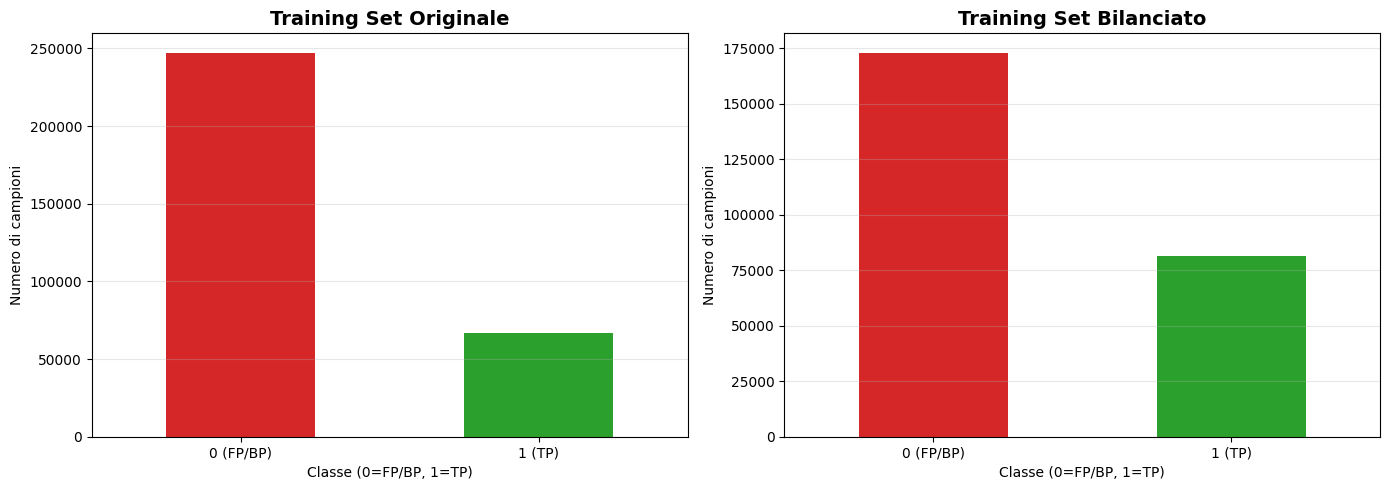

Grafico salvato in ../models/class_distribution_comparison.png


In [22]:
import matplotlib.pyplot as plt

# Crea confronto visivo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training originale
y_train_orig['BinaryIncidentGrade'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['#d62728', '#2ca02c']
)
axes[0].set_title('Training Set Originale', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Classe (0=FP/BP, 1=TP)')
axes[0].set_ylabel('Numero di campioni')
axes[0].set_xticklabels(['0 (FP/BP)', '1 (TP)'], rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Training bilanciato
y_train_bal.value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=['#d62728', '#2ca02c']
)
axes[1].set_title('Training Set Bilanciato', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Classe (0=FP/BP, 1=TP)')
axes[1].set_ylabel('Numero di campioni')
axes[1].set_xticklabels(['0 (FP/BP)', '1 (TP)'], rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../models/class_distribution_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Grafico salvato in ../models/class_distribution_comparison.png")

In [23]:
# Stampa statistiche finali
print("=" * 60)
print("RIEPILOGO BILANCIAMENTO")
print("=" * 60)

orig_counts = y_train_orig['BinaryIncidentGrade'].value_counts()
bal_counts = y_train_bal.value_counts()

print(f"\nTraining Originale:")
print(f"  Classe 0 (FP/BP): {orig_counts[0]:,} ({orig_counts[0]/len(y_train_orig)*100:.2f}%)")
print(f"  Classe 1 (TP):    {orig_counts[1]:,} ({orig_counts[1]/len(y_train_orig)*100:.2f}%)")
print(f"  Totale:           {len(y_train_orig):,}")
print(f"  Imbalance ratio:  {orig_counts[0]/orig_counts[1]:.2f}:1")

print(f"\nTraining Bilanciato:")
print(f"  Classe 0 (FP/BP): {bal_counts[0]:,} ({bal_counts[0]/len(y_train_bal)*100:.2f}%)")
print(f"  Classe 1 (TP):    {bal_counts[1]:,} ({bal_counts[1]/len(y_train_bal)*100:.2f}%)")
print(f"  Totale:           {len(y_train_bal):,}")
print(f"  Imbalance ratio:  {bal_counts[0]/bal_counts[1]:.2f}:1")

print(f"\nCampioni aggiunti:  {bal_counts[1] - orig_counts[1]:,}")
print(f"Incremento classe minoritaria: {((bal_counts[1] - orig_counts[1]) / orig_counts[1] * 100):.2f}%")
print("=" * 60)

RIEPILOGO BILANCIAMENTO

Training Originale:
  Classe 0 (FP/BP): 247,302 (78.70%)
  Classe 1 (TP):    66,928 (21.30%)
  Totale:           314,230
  Imbalance ratio:  3.70:1

Training Bilanciato:
  Classe 0 (FP/BP): 173,111 (67.98%)
  Classe 1 (TP):    81,537 (32.02%)
  Totale:           254,648
  Imbalance ratio:  2.12:1

Campioni aggiunti:  14,609
Incremento classe minoritaria: 21.83%


## Summary

**Obiettivo raggiunto:**
- ✓ Applicate mappature consistenti (feature_mappings.pkl) dal notebook 2
- ✓ Campioni TruePositive estratti dal test set e trasformati coerentemente
- ✓ Dataset salvato in `../data/processed_v4_balanced/`
